# MLP for independent weights

Sibling notebook to `MLP_for_correlated_weights.ipynb` / `MLP_for_anticorrelated_weights.ipynb`
-- same protocol, same real AAV9-derived `F_viab`/`J_viab` (from `AAV9_profile_model.ipynb`),
same `sequences`. Only `F_sel`/`J_sel` differ: here they carry NO shared trend with
`F_viab`/`J_viab` at all, via `initialize_indep_weights` -- a random permutation `sigma` of
the 20 amino acids is applied to `F_viab`'s (and `J_viab`'s) amino-acid axis, so each
position/pair keeps its ORIGINAL effect shape but reassigned to a different amino acid
identity, plus a bit of Gaussian noise on top (`noise_scale=0.2`, a fraction of
`F_viab`'s/`J_viab`'s own std). Unlike the correlated/anticorrelated notebooks, there's no
correlation dial here -- the relabeling destroys any per-cell correspondence with
`F_viab`/`J_viab`'s original amino-acid identities by construction.


## 0. Setup

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Must run before the first `import jax` anywhere -- same convention as DE_loopV1.ipynb /
# DEEPMLP_nnx_recovery.ipynb.

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, train_test_split
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

from flax import nnx
from functools import partial
from typing import Optional
import optax
from tqdm.auto import tqdm

from sequence_classesV1 import *
from analysisV1 import *
from initialize_weights import (
    load_F_viab_aav9_mlp, load_J_viab_aav9_mlp,
    initialize_correlated_weights, initialize_indep_weights, initialize_indep_weights,
    NUM_AMINO_ACIDS, NUM_POSITIONS,
)

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


In [3]:
class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Same building blocks as SimpleMLP
    (Linear + BatchNorm + Dropout + gelu), with input_dim=L*A: one-hot gives the network
    the categorical amino-acid structure for free, so it only has to learn each position's
    per-amino-acid effect -- and any pairwise coupling -- on top of that, instead of also
    having to rediscover the categorical structure from a raw integer index.
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


In [4]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L*A) one-hot encoded per-position amino-acid indicators
    y : (batch,) target log enrichment
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    """Fuses one epoch's mini-batch train_step calls into a single compiled nnx.scan
    instead of a Python for-loop issuing one XLA dispatch per batch."""
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


In [5]:
def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True, model=None):
    """
    model : optional existing ProfileMLP to continue training from (warm start) instead of
    initializing a fresh one.
    """
    rngs = nnx.Rngs(seed)
    if model is None:
        model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                            dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


## Part 1 — Build the protocol with realistic weights as in `AAV9_profile_model.ipynb`

`AAV9_profile_model.ipynb` (`Modelization_V1/MLP_regression/AAV_viability_test/`) trains a
small MLP (`ProfileMLP`: one-hot per-position sequence -> 2 hidden layers -> scalar score) on
`aav9.csv`, 68,776 real AAV9 capsid variants with a measured log-enrichment `target`. Two
things get pulled out of that trained network afterward:

- `F_viab` — a `(num_amino_acids=20, num_positions=7)` profile, from a SINGLE-mutant scan:
  for a batch of real background sequences, flip one position at a time and see how the
  model's predicted score shifts.
- `J_viab` — a `(7, 7, 20, 20)` pairwise coupling, from the same idea extended to a
  DOUBLE-mutant scan (flip two positions at once).

Both are exported to `.npy` (gitignored, a derived artifact) and loaded here via
`initialize_weights.py` — see that notebook for the full training/extraction code and
diagnostics (naive-vs-MLP agreement, etc.); this notebook starts from the result and treats
`F_viab`/`J_viab` as "ground truth" for what a REAL viability landscape looks like.

F_viab shape: (20, 7)
J_viab shape: (7, 7, 20, 20)


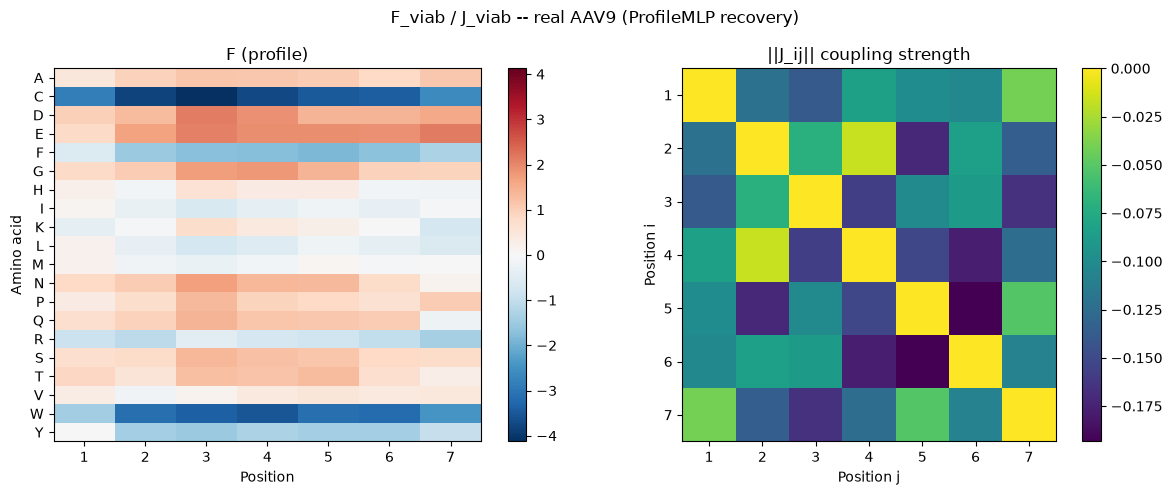

In [6]:
F_viab = load_F_viab_aav9_mlp()
J_viab = load_J_viab_aav9_mlp()

print(f"F_viab shape: {F_viab.shape}")
print(f"J_viab shape: {J_viab.shape}")

_ = plot_teacher_weights(F_viab, J_viab, title="F_viab / J_viab -- real AAV9 (ProfileMLP recovery)")
plt.show()

## 1. Recovery by MLP with independent weights 


In [7]:
noise_scale = 0.2


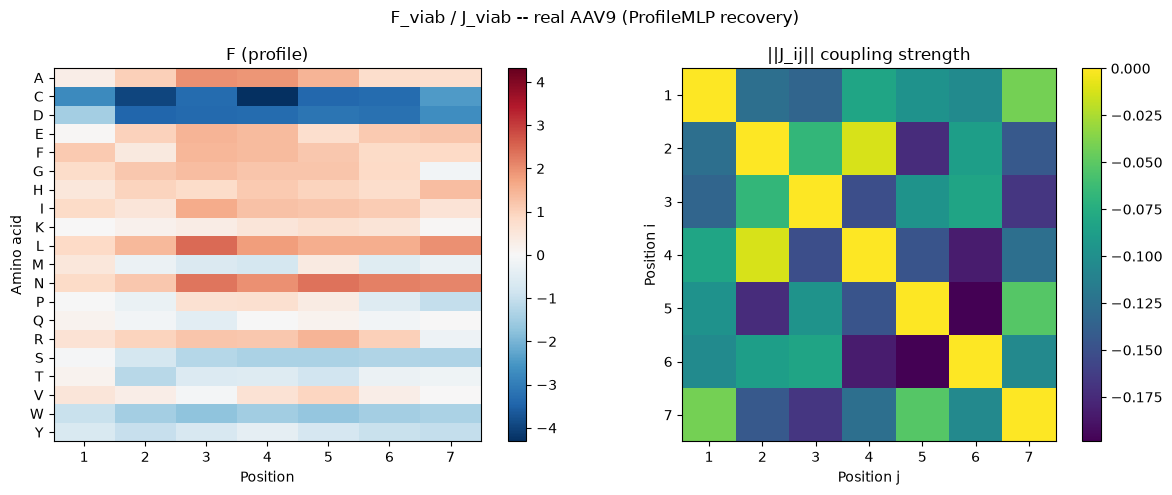

In [8]:
F_sel_indep, J_sel_indep = initialize_indep_weights(jax.random.key(10), F_viab, J_viab, noise_scale)
_ = plot_teacher_weights(F_sel_indep, J_sel_indep, title="F_viab / J_viab -- real AAV9 (ProfileMLP recovery)")
plt.show()


In [9]:
key = jax.random.key(0)
key, k_seq = jax.random.split(key)

N = 20_000
sequences = jax.random.randint(k_seq, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

protocol_indep = ProtocolV3(N0=1_000_000_000, N1=500_000_000, 
        dilution_factor=10, sequences=sequences, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel_indep, J_sel=J_sel_indep,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )

In [10]:
def compare_F(F_viab, F_sel, title, label_a="F_viab", label_b="F_sel"):
    """Same 3-panel recipe as AAV9_profile_model.ipynb's F comparisons: two heatmaps
    (shared RdBu_r scale) + a raw-entry scatter with Pearson r."""
    F_viab, F_sel = np.asarray(F_viab), np.asarray(F_sel)
    vmax = max(np.abs(F_viab).max(), np.abs(F_sel).max())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, F, panel_title in [(axes[0], F_viab, label_a), (axes[1], F_sel, label_b)]:
        im = ax.imshow(F, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_title(panel_title)
        ax.set_xlabel("Position"); ax.set_ylabel("Amino acid")
        ax.set_xticks(range(NUM_POSITIONS)); ax.set_xticklabels(range(1, NUM_POSITIONS + 1))
        ax.set_yticks(range(NUM_AMINO_ACIDS)); ax.set_yticklabels(AA_LABELS)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    r = pearson(F_viab.ravel(), F_sel.ravel())
    axes[2].scatter(F_viab.ravel(), F_sel.ravel(), s=14, alpha=0.6)
    lims = [min(F_viab.min(), F_sel.min()), max(F_viab.max(), F_sel.max())]
    axes[2].plot(lims, lims, "k--", alpha=0.5)
    axes[2].set_xlabel(label_a); axes[2].set_ylabel(label_b)
    axes[2].set_title(f"Pearson r = {r:.3f}")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def run_and_summarize(name, protocol):
    """Shows F_sel vs F_viab for this protocol's regime, runs one loop_DE() round, and plots
    viability-vs-selectivity score colored by abundance at every pipeline stage
    (plot_all_lambda_scores). Returns a one-row summary dict."""
    compare_F(F_viab, protocol.F_sel, f"{name} -- F_sel vs F_viab")

    viab_scores = np.array(protocol.compute_score(protocol.F_viab, protocol.J_viab))
    sel_scores  = np.array(protocol.compute_score(protocol.F_sel,  protocol.J_sel))
    score_corr  = pearson(viab_scores, sel_scores)
    p10         = precision_at_k(viab_scores, sel_scores, k_frac=0.10)

    protocol.loop_DE()
    lambda4 = np.array(protocol.lambda4)

    _ = plot_all_lambda_scores(protocol, title=f"{name} -- viability vs selectivity score, by pipeline stage")
    plt.show()

    return dict(regime=name, score_corr=score_corr, top10pct_overlap=p10,
                surviving=int((lambda4 > 0).sum()), pct_surviving=100 * (lambda4 > 0).mean(),
                entropy=shannon_entropy(lambda4))

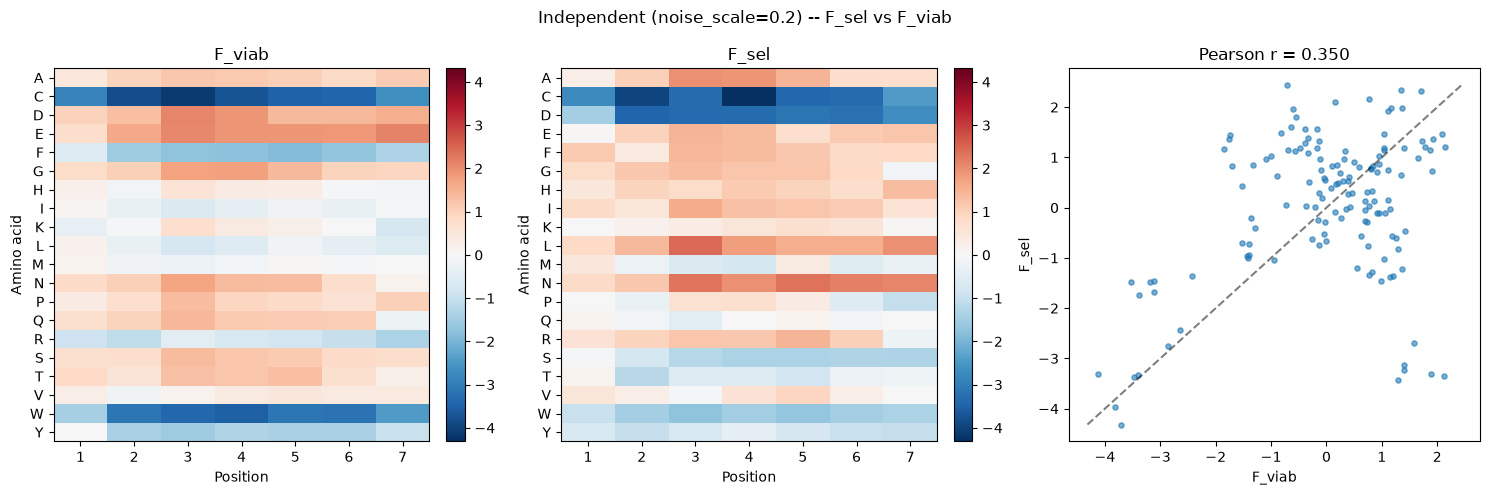

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   2%|▎         | 1/40 [00:00<00:04,  8.59it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

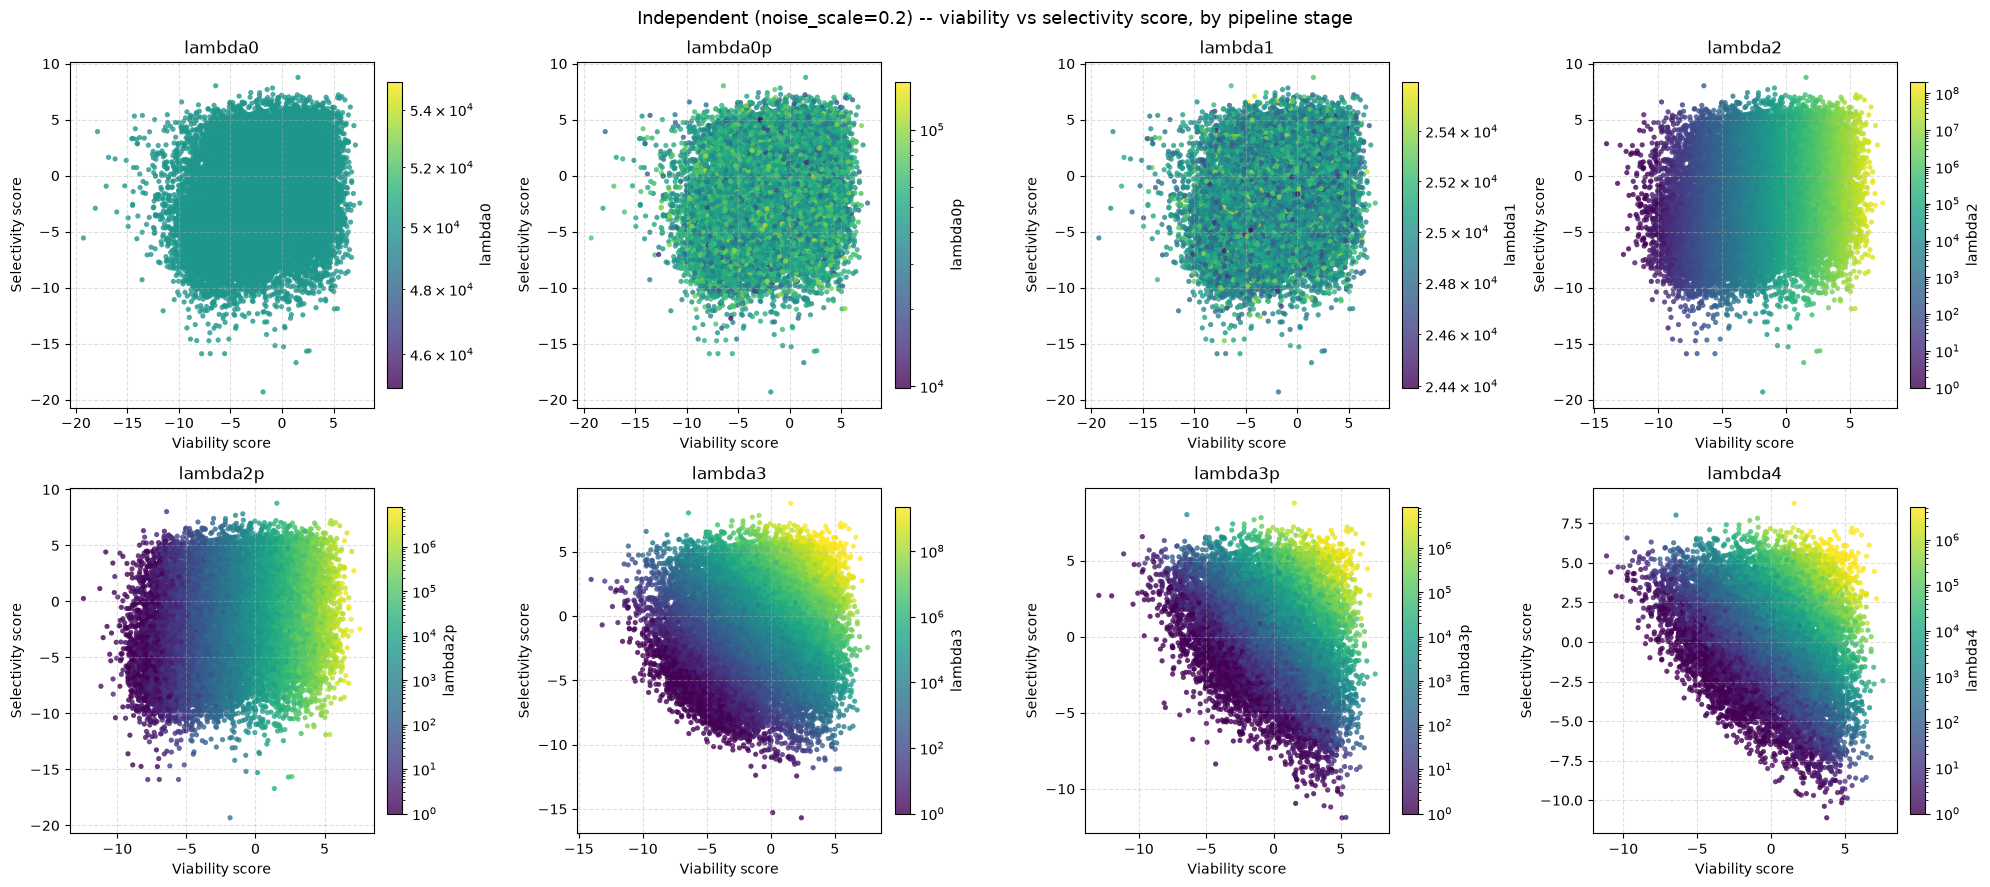

{'regime': 'Independent (noise_scale=0.2)',
 'score_corr': 0.2797846422493339,
 'top10pct_overlap': 0.144,
 'surviving': 11577,
 'pct_surviving': np.float64(57.885),
 'entropy': 6.412438253229148}

In [11]:
summary_indep = run_and_summarize(f"Independent (noise_scale={noise_scale})", protocol_indep)
summary_indep


In [12]:
def lambda_evolution_table(protocol, n_rounds=1):
    """
    Runs protocol.N_loop_DE(n_rounds) and tabulates total abundance + surviving diversity for
    every lambda checkpoint, in true pipeline order, one column group per round.
    """
    rounds = protocol.N_loop_DE(n_rounds)
    stages = ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]

    rows = []
    for round_idx, (bio_row, ngs_row) in enumerate(rounds):
        lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
        lambda0p, lambda2p, lambda3p = ngs_row
        stage_arrays = {
            "lambda0": lambda0, "lambda0p": lambda0p, "lambda1": lambda1,
            "lambda2": lambda2, "lambda2p": lambda2p, "lambda3": lambda3,
            "lambda3p": lambda3p, "lambda4": lambda4,
        }
        for stage in stages:
            arr = np.asarray(stage_arrays[stage])
            rows.append(dict(
                round=round_idx, stage=stage,
                total=float(arr.sum()), n_surviving=int((arr > 0).sum()),
            ))

    df = pd.DataFrame(rows)
    df["pct_surviving"] = 100 * df["n_surviving"] / protocol.d0
    return df.pivot(index="stage", columns="round", values=["total", "n_surviving", "pct_surviving"]).reindex(stages)

lambda_evolution_table(protocol_indep, n_rounds=1)

Directed evolution rounds:   0%|          | 0/1 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:  92%|█████████▎| 37/40 [00:00<00:00, 367.58it/s]

Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  1.01it/s]

Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  1.01it/s]

,total,n_surviving,pct_surviving
round,0,0,0
stage,,,
lambda0,1.000000e+09,20000.0,100.000
lambda0p,1.000870e+09,20000.0,100.000
lambda1,4.999818e+08,20000.0,100.000
lambda2,2.546196e+10,19909.0,99.545
lambda2p,9.918714e+08,18877.0,94.385
lambda3,4.123922e+11,17302.0,86.510
lambda3p,9.885487e+08,11604.0,58.020
lambda4,9.999628e+08,11569.0,57.845


In [13]:
rounds = protocol_indep.N_loop_DE(1)
bio_row, ngs_row = rounds[0]
lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
lambda0p, lambda2p, lambda3p = ngs_row

lambda1 = np.asarray(lambda1)
lambda2 = np.asarray(lambda2)
lambda3 = np.asarray(lambda3)

eps = 1.0  # pseudocount of 1 read -- avoids log(0) and matches the floor of the real
           # AAV9 log-enrichment scale (aav9.csv 'target' ranges ~[-12, 7.5])

log_enr_viab = np.log((lambda2 + eps) / (lambda1 + eps))  # target1 -- viability phase
log_enr_sel  = np.log((lambda3 + eps) / (lambda2 + eps))  # target2 -- selectivity phase

print(f"log_enr_viab: min={log_enr_viab.min():.2f}  max={log_enr_viab.max():.2f}  mean={log_enr_viab.mean():.2f}")
print(f"log_enr_sel : min={log_enr_sel.min():.2f}  max={log_enr_sel.max():.2f}  mean={log_enr_sel.mean():.2f}")

Directed evolution rounds:   0%|          | 0/1 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  1.13it/s]

Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  1.13it/s]

log_enr_viab: min=-10.14  max=9.03  mean=-0.87
log_enr_sel : min=-14.35  max=8.41  mean=-1.72


## Export to CSV (cached per experiment parameters)

Filename encodes the diversity and the parameters that change the resulting distribution
(`T_sel`, `T_viab`, `noise`) -- e.g. `diversite20000_Tsel1_Tviab1_noise05.csv` for
`d0=20_000`, `T_sel=1`, `T_viab=1`, `noise_viab=noise_sel=0.5`. If that exact file already
exists on disk it's loaded instead of re-running the (slow) simulation.

In [14]:
def dataset_filename(protocol, label):
    def fmt(v):
        return f"{float(v):g}".replace(".", "")

    if protocol.noise_viab == protocol.noise_sel:
        noise_part = f"noise{fmt(protocol.noise_viab)}"
    else:
        noise_part = f"noiseviab{fmt(protocol.noise_viab)}_noisesel{fmt(protocol.noise_sel)}"

    return (f"diversity{protocol.d0}_Tsel{fmt(protocol._T_sel)}"
            f"_Tviab{fmt(protocol._T_viab)}_{noise_part}_{label}.csv")


def build_or_load_dataset(protocol, sequences, log_enr_viab, log_enr_sel, label):
    """(sequence, target1=viability log-enrichment, target2=selectivity log-enrichment)
    dataset for this protocol's parameters. `label` distinguishes the F_sel/J_sel flavor
    (correlated/anticorrelated/indep) so the three sibling notebooks -- which otherwise share
    the same diversity/T_sel/T_viab/noise parameters -- don't collide on the same CSV. Loads
    the CSV from disk if it was already generated for this exact (diversity, T_sel, T_viab,
    noise, label) combination, else builds and saves it."""
    path = dataset_filename(protocol, label)
    if os.path.exists(path):
        print(f"{path} already exists -- loading from disk")
        return pd.read_csv(path)

    seq_strings = ["".join(AA_LABELS[a] for a in row) for row in np.asarray(sequences)]
    df = pd.DataFrame({"sequence": seq_strings, "target1": log_enr_viab, "target2": log_enr_sel})
    df.to_csv(path, index=False)
    print(f"saved {path} ({len(df)} rows)")
    return df


dataset_indep = build_or_load_dataset(protocol_indep, sequences, log_enr_viab, log_enr_sel, label="ind")
dataset_indep.head()

diversity20000_Tsel1_Tviab1_noise05_ind.csv already exists -- loading from disk


,sequence,target1,target2
0,DDTSNIP,4.790522,-4.675281
1,MSTDFNG,3.657291,-4.290627
2,CQNSWCF,-3.332847,-3.899725
3,CRCHSEA,-6.730421,-3.401197
4,QAFNMTQ,0.394225,3.848169


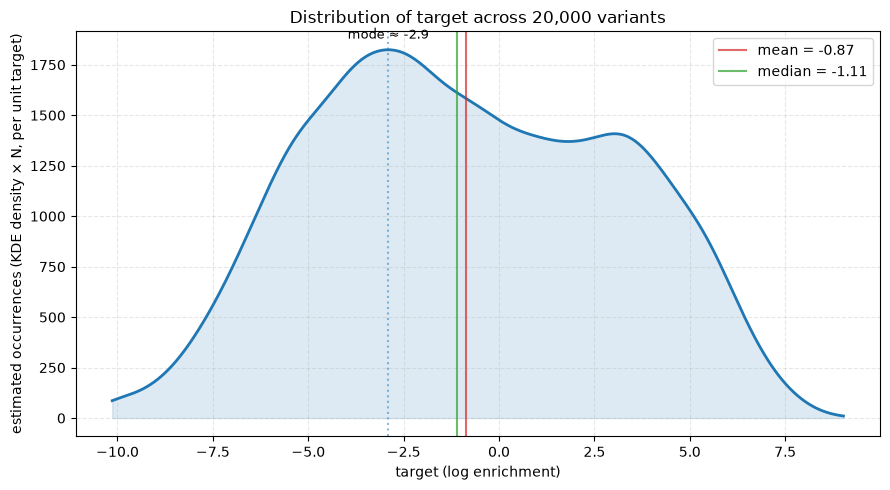

detected mode(s) at target ≈ [-2.91]


In [15]:
t_viab = dataset_indep["target1"].to_numpy()

# Smooth density (Gaussian KDE), not a binned histogram -- rescaled by N so the curve reads
# as an estimated occurrence count per unit of target (area under the curve over a range ~=
# expected number of variants in that range), rather than a probability density.
grid = np.linspace(t_viab.min(), t_viab.max(), 1000)
kde = gaussian_kde(t_viab, bw_method=0.15)
occurrences = kde(grid) * len(t_viab)

# Auto-detect modes (and, if bimodal, the valley between them) instead of eyeballing the plot.
peaks, _ = find_peaks(occurrences, prominence=occurrences.max() * 0.05)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(grid, occurrences, color="tab:blue", lw=2)
ax.fill_between(grid, occurrences, alpha=0.15, color="tab:blue")

for p in peaks:
    ax.axvline(grid[p], color="tab:blue", linestyle=":", alpha=0.5)
    ax.annotate(f"mode ≈ {grid[p]:.1f}", (grid[p], occurrences[p]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

if len(peaks) >= 2:
    lo, hi = peaks[0], peaks[-1]
    valley = lo + np.argmin(occurrences[lo:hi + 1])
    ax.axvline(grid[valley], color="gray", linestyle="--", alpha=0.6)
    ax.annotate(f"valley ≈ {grid[valley]:.1f}", (grid[valley], occurrences[valley]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color="gray")

ax.axvline(t_viab.mean(), color="tab:red", linestyle="-", alpha=0.7, label=f"mean = {t_viab.mean():.2f}")
ax.axvline(np.median(t_viab), color="tab:green", linestyle="-", alpha=0.7, label=f"median = {np.median(t_viab):.2f}")

ax.set_xlabel("target (log enrichment)")
ax.set_ylabel("estimated occurrences (KDE density × N, per unit target)")
ax.set_title(f"Distribution of target across {len(t_viab):,} variants")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"detected mode(s) at target ≈ {np.round(grid[peaks], 2)}")


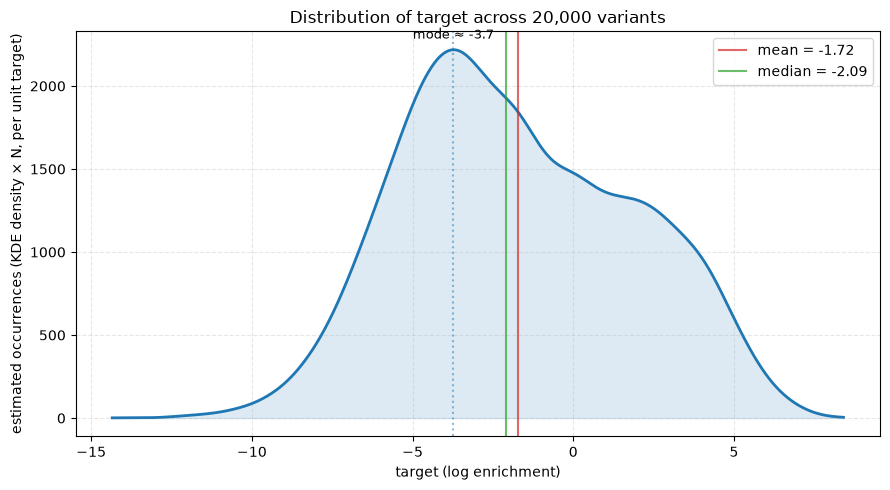

detected mode(s) at target ≈ [-3.73]


In [16]:
t_sel = dataset_indep["target2"].to_numpy()

# Smooth density (Gaussian KDE), not a binned histogram -- rescaled by N so the curve reads
# as an estimated occurrence count per unit of target (area under the curve over a range ~=
# expected number of variants in that range), rather than a probability density.
grid = np.linspace(t_sel.min(), t_sel.max(), 1000)
kde = gaussian_kde(t_sel, bw_method=0.15)
occurrences = kde(grid) * len(t_sel)

# Auto-detect modes (and, if bimodal, the valley between them) instead of eyeballing the plot.
peaks, _ = find_peaks(occurrences, prominence=occurrences.max() * 0.05)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(grid, occurrences, color="tab:blue", lw=2)
ax.fill_between(grid, occurrences, alpha=0.15, color="tab:blue")

for p in peaks:
    ax.axvline(grid[p], color="tab:blue", linestyle=":", alpha=0.5)
    ax.annotate(f"mode ≈ {grid[p]:.1f}", (grid[p], occurrences[p]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

if len(peaks) >= 2:
    lo, hi = peaks[0], peaks[-1]
    valley = lo + np.argmin(occurrences[lo:hi + 1])
    ax.axvline(grid[valley], color="gray", linestyle="--", alpha=0.6)
    ax.annotate(f"valley ≈ {grid[valley]:.1f}", (grid[valley], occurrences[valley]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color="gray")

ax.axvline(t_sel.mean(), color="tab:red", linestyle="-", alpha=0.7, label=f"mean = {t_sel.mean():.2f}")
ax.axvline(np.median(t_sel), color="tab:green", linestyle="-", alpha=0.7, label=f"median = {np.median(t_sel):.2f}")

ax.set_xlabel("target (log enrichment)")
ax.set_ylabel("estimated occurrences (KDE density × N, per unit target)")
ax.set_title(f"Distribution of target across {len(t_sel):,} variants")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"detected mode(s) at target ≈ {np.round(grid[peaks], 2)}")


## ProfileMLP recovery: predicting log-enrichment from sequence, retrieving F

Same recipe as `AAV9_profile_model.ipynb` (`ProfileMLP` + `train_profile_mlp`, already defined
in Setup above), applied here to `dataset_indep` (the simulated CSV) instead of the real
`aav9.csv`: one `ProfileMLP` instance trained on `target1` (viability log-enrichment) and one
trained on `target2` (selectivity log-enrichment), then `F_viab_hat`/`F_sel_hat` pulled back out
via a single-mutant scan and compared against the ground-truth `F_viab`/`F_sel_indep` used to
generate the data -- plus top-k recovery plots showing how well each model ranks the actual
best variants on held-out data.

In [17]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


@nnx.jit
def predict_scores(model, x):
    return model(x, train=False)


### ------------ Sequence string -> raw indices -> one-hot ------------ ###
lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes  = np.frombuffer("".join(dataset_indep["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(dataset_indep), NUM_POSITIONS)
seq_oh     = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix].reshape(len(dataset_indep), -1)

y_viab_all = dataset_indep["target1"].to_numpy()
y_sel_all  = dataset_indep["target2"].to_numpy()

idx_train, idx_test = train_test_split(np.arange(len(dataset_indep)), test_size=0.5, random_state=0)
X_train_full, X_test = seq_oh[idx_train], seq_oh[idx_test]

print(f"X_train_full shape: {X_train_full.shape}  X_test shape: {X_test.shape}")

X_train_full shape: (10000, 140)  X_test shape: (10000, 140)


In [18]:
y_viab_train, y_viab_test = y_viab_all[idx_train], y_viab_all[idx_test]
Xtr_viab, ytr_viab, Xva_viab, yva_viab = split_train_val(X_train_full, y_viab_train, val_frac=0.15, seed=0)
print(f"ProfileMLP (viab) -- train: {len(Xtr_viab):,}  val: {len(Xva_viab):,}  test: {len(X_test):,}")

model_viab, hist_viab = train_profile_mlp(Xtr_viab, ytr_viab, Xva_viab, yva_viab, seed=0)

ProfileMLP (viab) -- train: 8,500  val: 1,500  test: 10,000


Training ProfileMLP:   0%|          | 0/300 [00:00<?, ?it/s]

Training ProfileMLP:   0%|          | 1/300 [00:04<22:35,  4.53s/it]

Training ProfileMLP:   4%|▎         | 11/300 [00:04<01:28,  3.26it/s]

Training ProfileMLP:   6%|▌         | 18/300 [00:04<00:46,  6.03it/s]

...

Training ProfileMLP:  55%|█████▌    | 165/300 [00:06<00:01, 77.35it/s]

Training ProfileMLP:  58%|█████▊    | 173/300 [00:06<00:01, 76.12it/s]

Training ProfileMLP:  61%|██████    | 182/300 [00:06<00:01, 79.62it/s]

Training ProfileMLP:  62%|██████▏   | 185/300 [00:06<00:04, 27.07it/s]

Early stopping at epoch 185 (best val MSE=0.5468)


In [19]:
y_sel_train, y_sel_test = y_sel_all[idx_train], y_sel_all[idx_test]
Xtr_sel, ytr_sel, Xva_sel, yva_sel = split_train_val(X_train_full, y_sel_train, val_frac=0.15, seed=1)
print(f"ProfileMLP (sel) -- train: {len(Xtr_sel):,}  val: {len(Xva_sel):,}  test: {len(X_test):,}")

model_sel, hist_sel = train_profile_mlp(Xtr_sel, ytr_sel, Xva_sel, yva_sel, seed=1)

ProfileMLP (sel) -- train: 8,500  val: 1,500  test: 10,000


Training ProfileMLP:   0%|          | 0/300 [00:00<?, ?it/s]

Training ProfileMLP:   0%|          | 1/300 [00:00<04:26,  1.12it/s]

Training ProfileMLP:   3%|▎         | 10/300 [00:01<00:22, 13.17it/s]

Training ProfileMLP:   6%|▌         | 18/300 [00:01<00:11, 24.00it/s]

...

Training ProfileMLP:  30%|██▉       | 89/300 [00:02<00:02, 74.45it/s]

Training ProfileMLP:  32%|███▏      | 97/300 [00:02<00:02, 75.75it/s]

Training ProfileMLP:  35%|███▌      | 105/300 [00:02<00:02, 74.60it/s]

Training ProfileMLP:  36%|███▋      | 109/300 [00:02<00:04, 46.26it/s]

Early stopping at epoch 109 (best val MSE=1.1491)


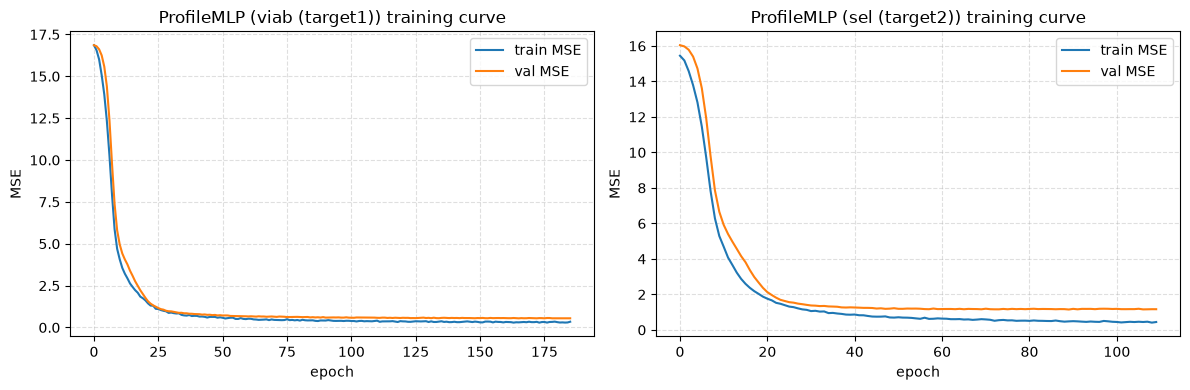

target1 (viab) -- Pearson r (test): 0.9829
target2 (sel)  -- Pearson r (test): 0.9521


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, name in [(axes[0], hist_viab, "viab (target1)"), (axes[1], hist_sel, "sel (target2)")]:
    ax.plot(hist["train_loss"], label="train MSE")
    ax.plot(hist["val_loss"],   label="val MSE")
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
    ax.set_title(f"ProfileMLP ({name}) training curve")
    ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

pred_viab_test = np.asarray(predict_scores(model_viab, jnp.asarray(X_test)))
pred_sel_test  = np.asarray(predict_scores(model_sel,  jnp.asarray(X_test)))

print(f"target1 (viab) -- Pearson r (test): {pearson(y_viab_test, pred_viab_test):.4f}")
print(f"target2 (sel)  -- Pearson r (test): {pearson(y_sel_test,  pred_sel_test):.4f}")

In [21]:
def extract_effective_F(model, backgrounds, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS, batch_size=8192):
    """
    Single-mutant scan against background sequences: for a background s and mutation p->a,
    M(s^{p->a}) - M(s) isolates f_p(a) only up to terms that depend on s's other positions.
    Averaged over many backgrounds, F is recovered up to a global additive constant. Same
    recipe as AAV9_profile_model.ipynb's extract_effective_F.
    """
    backgrounds = np.asarray(backgrounds, dtype=np.int64)
    M = backgrounds.shape[0]

    n_single       = M * L * A
    single_mutants = np.repeat(backgrounds, L * A, axis=0)
    pos_pattern    = np.tile(np.repeat(np.arange(L), A), M)
    aa_pattern     = np.tile(np.tile(np.arange(A), L), M)
    single_mutants[np.arange(n_single), pos_pattern] = aa_pattern

    x_all    = np.concatenate([backgrounds, single_mutants], axis=0)              # (n, L) raw indices
    x_all_oh = np.eye(A, dtype=np.float32)[x_all].reshape(x_all.shape[0], -1)     # (n, L*A) one-hot

    scores_chunks = []
    for start in range(0, x_all_oh.shape[0], batch_size):
        chunk = jnp.asarray(x_all_oh[start : start + batch_size])
        scores_chunks.append(np.asarray(predict_scores(model, chunk)))
    scores = np.concatenate(scores_chunks)

    mean_score    = scores.mean()
    single_scores = scores[M:].reshape(M, L, A)

    F_flat = single_scores.mean(axis=0) - mean_score  # (L, A)
    return F_flat.T.astype(np.float32)                # (A, L)


rng_bg        = np.random.default_rng(0)
M_backgrounds = 256
bg_idx        = rng_bg.choice(seq_matrix.shape[0], size=M_backgrounds, replace=False)
backgrounds   = seq_matrix[bg_idx]

F_viab_hat = extract_effective_F(model_viab, backgrounds)
F_sel_hat  = extract_effective_F(model_sel,  backgrounds)

print(f"F_viab_hat shape: {F_viab_hat.shape}  F_sel_hat shape: {F_sel_hat.shape}")

F_viab_hat shape: (20, 7)  F_sel_hat shape: (20, 7)


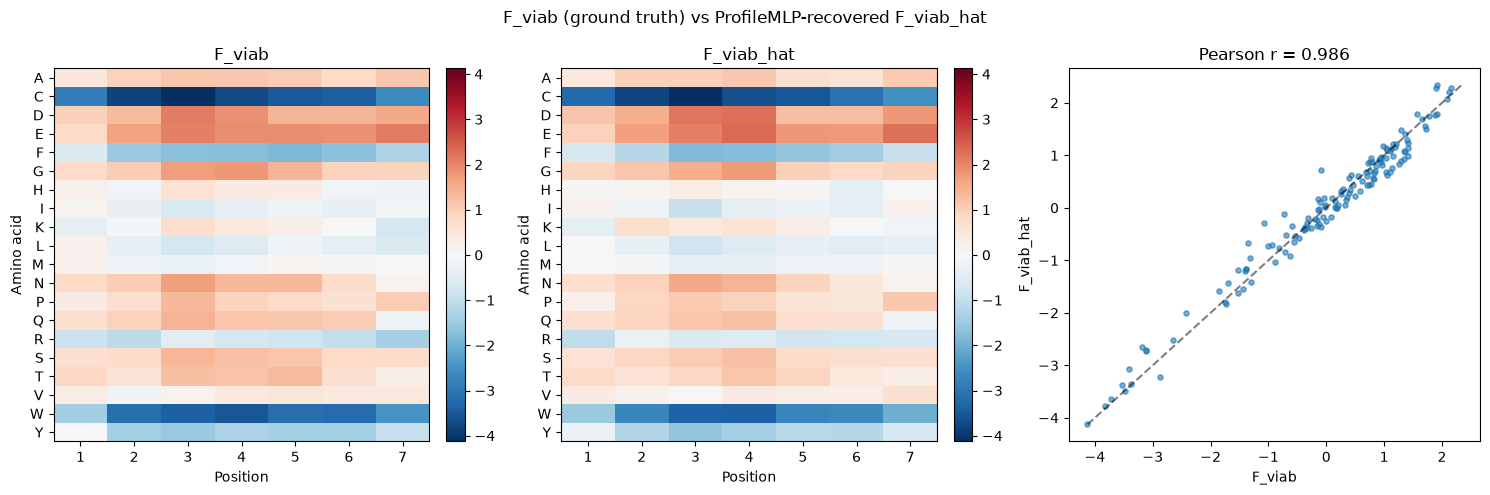

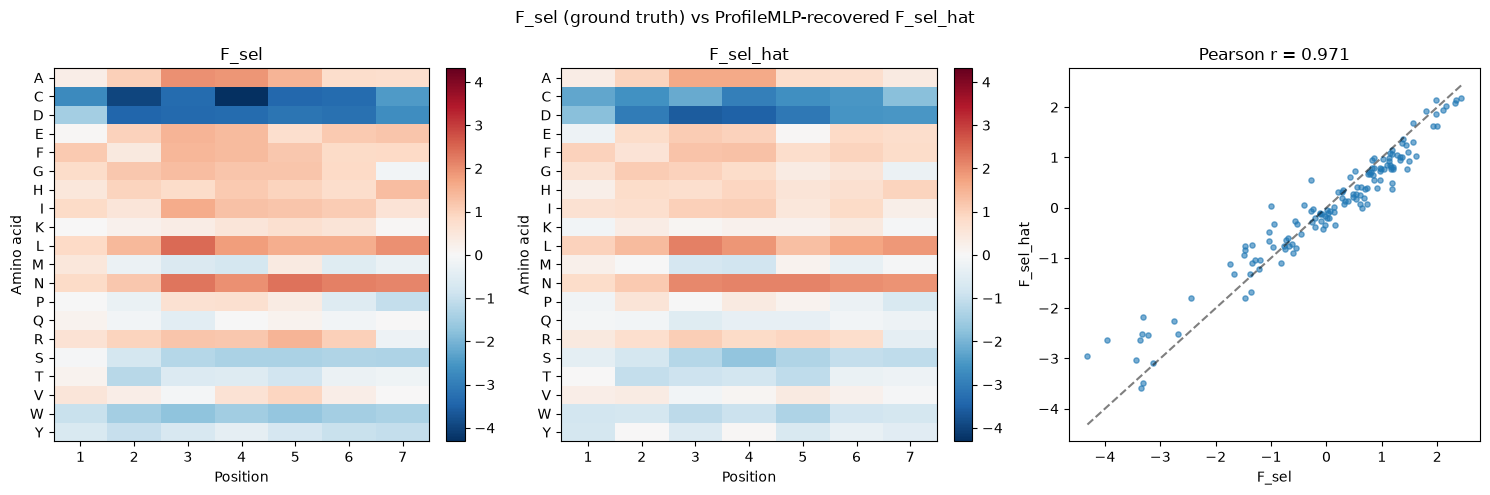

In [22]:
compare_F(F_viab, F_viab_hat, "F_viab (ground truth) vs ProfileMLP-recovered F_viab_hat",
          label_a="F_viab", label_b="F_viab_hat")
compare_F(F_sel_indep, F_sel_hat, "F_sel (ground truth) vs ProfileMLP-recovered F_sel_hat",
          label_a="F_sel", label_b="F_sel_hat")

### How well are the best variants predicted? (held-out top-k recovery)

Held-out (test) top-k recovery -- viability (target1):
  Top   1%   precision = 0.600   (random baseline = 0.010)
  Top   5%   precision = 0.770   (random baseline = 0.050)
  Top  10%   precision = 0.851   (random baseline = 0.100)
  Top  20%   precision = 0.917   (random baseline = 0.200)


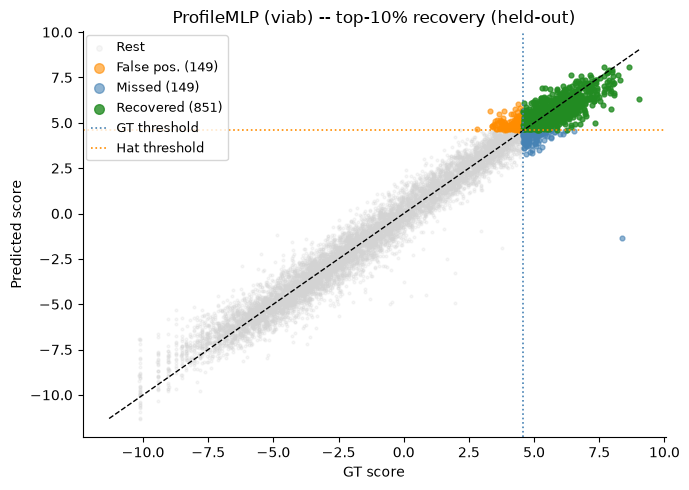


Held-out (test) top-k recovery -- selectivity (target2):
  Top   1%   precision = 0.490   (random baseline = 0.010)
  Top   5%   precision = 0.656   (random baseline = 0.050)
  Top  10%   precision = 0.777   (random baseline = 0.100)
  Top  20%   precision = 0.875   (random baseline = 0.200)


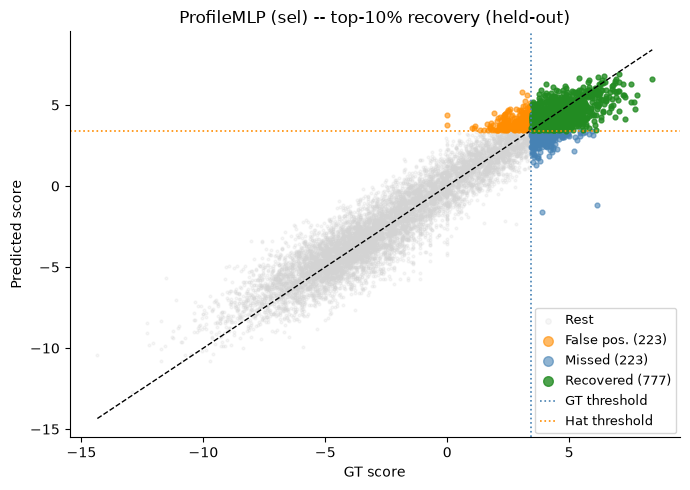

In [23]:
print("Held-out (test) top-k recovery -- viability (target1):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_viab_test, pred_viab_test, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_viab_test, pred_viab_test, k_frac=0.10,
                          title="ProfileMLP (viab) -- top-10% recovery (held-out)")
plt.show()

print("\nHeld-out (test) top-k recovery -- selectivity (target2):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_sel_test, pred_sel_test, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_sel_test, pred_sel_test, k_frac=0.10,
                          title="ProfileMLP (sel) -- top-10% recovery (held-out)")
plt.show()

### On a another dataset

In [24]:
key = jax.random.key(42)
key, k_seq = jax.random.split(key)

N = 2_000_000
sequences2 = jax.random.randint(k_seq, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

protocol_indep2 = ProtocolV3(N0=1_000_000_000, N1=500_000_000, 
        dilution_factor=10, sequences=sequences2, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel_indep, J_sel=J_sel_indep,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )

In [25]:
rounds = protocol_indep2.N_loop_DE(1)
bio_row, ngs_row = rounds[0]
lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
lambda0p, lambda2p, lambda3p = ngs_row

lambda1 = np.asarray(lambda1)
lambda2 = np.asarray(lambda2)
lambda3 = np.asarray(lambda3)
lambda1_big, lambda2_big, lambda3_big = lambda1, lambda2, lambda3  # keep distinct names for later reference

eps = 1.0  # pseudocount of 1 read -- avoids log(0) and matches the floor of the real
           # AAV9 log-enrichment scale (aav9.csv 'target' ranges ~[-12, 7.5])

log_enr_viab = np.log((lambda2 + eps) / (lambda1 + eps))  # target1 -- viability phase
log_enr_sel  = np.log((lambda3 + eps) / (lambda2 + eps))  # target2 -- selectivity phase

print(f"log_enr_viab: min={log_enr_viab.min():.2f}  max={log_enr_viab.max():.2f}  mean={log_enr_viab.mean():.2f}")
print(f"log_enr_sel : min={log_enr_sel.min():.2f}  max={log_enr_sel.max():.2f}  mean={log_enr_sel.mean():.2f}")

Directed evolution rounds:   0%|          | 0/1 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:  15%|█▌        | 6/40 [00:00<00:00, 59.98it/s]

PCR cycles:  57%|█████▊    | 23/40 [00:00<00:00, 122.86it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

...

PCR cycles:  65%|██████▌   | 26/40 [00:00<00:00, 118.74it/s]

PCR cycles:  95%|█████████▌| 38/40 [00:00<00:00, 118.78it/s]

Directed evolution rounds: 100%|██████████| 1/1 [00:05<00:00,  5.10s/it]

Directed evolution rounds: 100%|██████████| 1/1 [00:05<00:00,  5.10s/it]

log_enr_viab: min=-5.79  max=15.89  mean=-4.17
log_enr_sel : min=-14.06  max=10.15  mean=-0.23


In [26]:
dataset_indep2 = build_or_load_dataset(protocol_indep2, sequences2, log_enr_viab, log_enr_sel, label="ind")
dataset_indep2.head()

diversity2000000_Tsel1_Tviab1_noise05_ind.csv already exists -- loading from disk


,sequence,target1,target2
0,GPFPSFC,-1.950661,-3.401197
1,WTSATKN,-5.631212,0.000000
2,QKCDGIY,-5.365976,0.000000
3,WHAWFWW,-5.568345,0.000000
4,HQWMAEI,-5.468060,0.000000


In [27]:
### No retraining here -- model_viab/model_sel are the SAME models trained earlier on the
### 20,000-variant dataset. This just encodes the 200,000 new sequences and runs inference.
seq_bytes2  = np.frombuffer("".join(dataset_indep2["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix2 = lut[seq_bytes2].reshape(len(dataset_indep2), NUM_POSITIONS)
X_big       = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix2].reshape(len(dataset_indep2), -1)

y_viab_big = dataset_indep2["target1"].to_numpy()
y_sel_big  = dataset_indep2["target2"].to_numpy()

print(f"X_big shape: {X_big.shape}")

X_big shape: (2000000, 140)


In [28]:
pred_viab_big = np.asarray(predict_scores(model_viab, jnp.asarray(X_big)))
pred_sel_big  = np.asarray(predict_scores(model_sel,  jnp.asarray(X_big)))

print(f"target1 (viab) -- Pearson r on {len(dataset_indep2):,} unseen variants: {pearson(y_viab_big, pred_viab_big):.4f}")
print(f"target2 (sel)  -- Pearson r on {len(dataset_indep2):,} unseen variants: {pearson(y_sel_big,  pred_sel_big):.4f}")

target1 (viab) -- Pearson r on 2,000,000 unseen variants: 0.2642
target2 (sel)  -- Pearson r on 2,000,000 unseen variants: 0.4058


Top-k recovery on 2,000,000 unseen variants -- viability (target1):


  Top   1%   precision = 0.209   (random baseline = 0.010)


  Top   5%   precision = 0.223   (random baseline = 0.050)


  Top  10%   precision = 0.222   (random baseline = 0.100)


  Top  20%   precision = 0.222   (random baseline = 0.200)


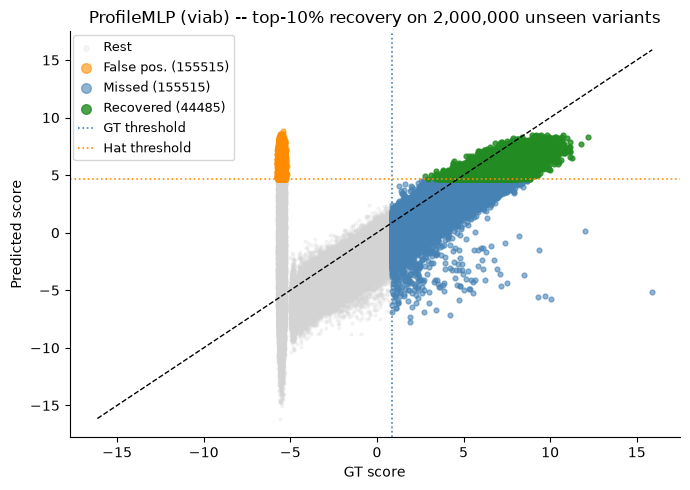


Top-k recovery on 2,000,000 unseen variants -- selectivity (target2):
  Top   1%   precision = 0.198   (random baseline = 0.010)


  Top   5%   precision = 0.218   (random baseline = 0.050)
  Top  10%   precision = 0.247   (random baseline = 0.100)


  Top  20%   precision = 0.344   (random baseline = 0.200)


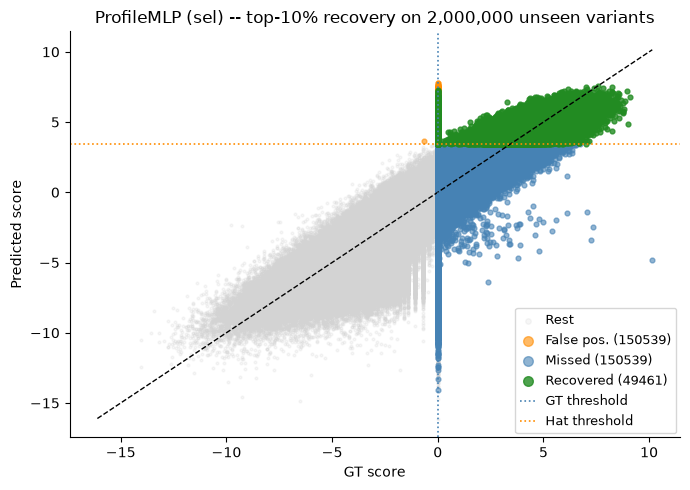

In [29]:
print(f"Top-k recovery on {len(dataset_indep2):,} unseen variants -- viability (target1):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_viab_big, pred_viab_big, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_viab_big, pred_viab_big, k_frac=0.10,
                          title=f"ProfileMLP (viab) -- top-10% recovery on {len(dataset_indep2):,} unseen variants")
plt.show()

print(f"\nTop-k recovery on {len(dataset_indep2):,} unseen variants -- selectivity (target2):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_sel_big, pred_sel_big, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_sel_big, pred_sel_big, k_frac=0.10,
                          title=f"ProfileMLP (sel) -- top-10% recovery on {len(dataset_indep2):,} unseen variants")
plt.show()

## Stratified metrics: detection-floor variants vs. the rest

`target1`/`target2` are ratios of noisy Poisson/Binomial COUNTS (`lambda1`/`lambda2`/`lambda3`)
plus the `eps` pseudocount. When a count hits exactly `0` (no capsids produced, or none
survived selection), the resulting label collapses to a value that only depends on the OTHER
count -- e.g. `target2 = log(eps / (lambda2 + eps))` whenever `lambda3 == 0`, regardless of how
bad the true selectivity score actually was. Many genuinely different sequences land on
`lambda2 == 0` or `lambda3 == 0` and therefore share (near-)identical labels (see the printed
floor fractions below). Since the MLP is trained with MSE against these labels, it has no
gradient signal to tell those sequences apart either, so it (correctly, given the data)
predicts similarly for all of them -- this is what shows up as "clumping" in the recovery
scatter plots above.

This isn't an `eps` bug -- shrinking `eps` only moves the floor value, it doesn't stop
different sequences from sharing the same small integer count. It's a real detection-limit
effect (same as a real NGS "zero reads" variant), so it's split out here rather than "fixed":
metrics computed only on the in-range (non-floor) subset show how well the model actually
ranks variants where the data contains real signal.

Top-k recovery, in-range only -- viability (target1, 420,790 variants):
  Top   1%   precision = 0.482   (random baseline = 0.010)
  Top   5%   precision = 0.715   (random baseline = 0.050)
  Top  10%   precision = 0.805   (random baseline = 0.100)
  Top  20%   precision = 0.889   (random baseline = 0.200)


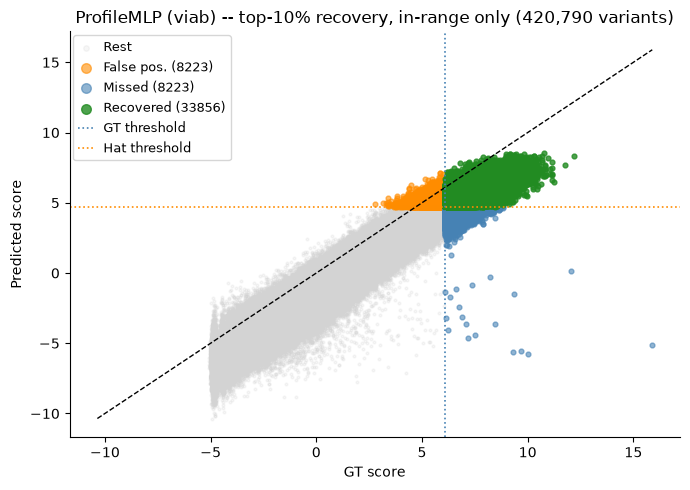


Top-k recovery, in-range only -- selectivity (target2, 312,663 variants):
  Top   1%   precision = 0.419   (random baseline = 0.010)
  Top   5%   precision = 0.630   (random baseline = 0.050)
  Top  10%   precision = 0.736   (random baseline = 0.100)
  Top  20%   precision = 0.834   (random baseline = 0.200)


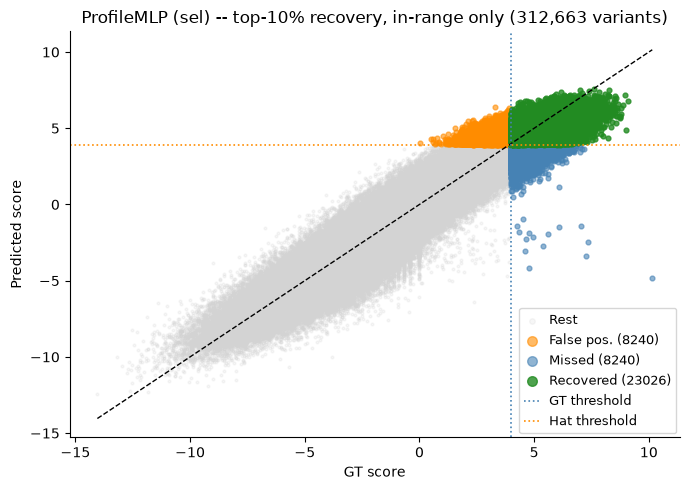

In [30]:
### Same top-10% recovery plot as before, but restricted to the in-range (non-censored)
### variants -- drops the at-floor ones (lambda2 == 0 for viab, lambda3 == 0 for sel) whose
### labels carry no real ranking information (see "Stratified metrics" discussion above).
at_floor_viab = (lambda2_big == 0)          # target1 degenerate whenever lambda2 == 0
at_floor_sel  = (lambda3_big == 0)          # target2 degenerate whenever lambda3 == 0
in_range_viab = ~at_floor_viab
in_range_sel  = ~at_floor_sel

y_viab_in_range    = y_viab_big[in_range_viab]
pred_viab_in_range = pred_viab_big[in_range_viab]
y_sel_in_range      = y_sel_big[in_range_sel]
pred_sel_in_range   = pred_sel_big[in_range_sel]

print(f"Top-k recovery, in-range only -- viability (target1, {len(y_viab_in_range):,} variants):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_viab_in_range, pred_viab_in_range, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_viab_in_range, pred_viab_in_range, k_frac=0.10,
                          title=f"ProfileMLP (viab) -- top-10% recovery, in-range only ({len(y_viab_in_range):,} variants)")
plt.show()

print(f"\nTop-k recovery, in-range only -- selectivity (target2, {len(y_sel_in_range):,} variants):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_sel_in_range, pred_sel_in_range, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_sel_in_range, pred_sel_in_range, k_frac=0.10,
                          title=f"ProfileMLP (sel) -- top-10% recovery, in-range only ({len(y_sel_in_range):,} variants)")
plt.show()

## Do the TRUE global-optimum variants get recognized by the MLP?

Everything above measured top-k recovery WITHIN a randomly-sampled pool (20,000 / 2,000,000
sequences, out of `20**7 ~= 1.28e9` possible ones) -- but the actual BEST sequences (the
global optimum of the ground-truth `F`/`J` score) are so rare in that space that they're
essentially guaranteed to never land in any such random sample. This section finds those
sequences directly -- an exhaustive brute-force scan over the full sequence space using the
EXACT `F_viab`/`J_viab` and `F_sel_indep`/`J_sel_indep` (no MLP, no sampling: `20**7` is small
enough to just score every single sequence and keep the top-k) -- then checks whether the
trained `ProfileMLP` still recognizes them as exceptional, despite never having seen them
during training.

In [31]:
def compute_score_array(seq, F, J, L=NUM_POSITIONS):
    """Same formula as Protocol.compute_score, decoupled from a Protocol instance so it can
    be applied to an arbitrary (n, L) array of raw-index sequences."""
    scores = jnp.sum(F[seq, jnp.arange(L)], axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            scores = scores + J[i, j, seq[:, i], seq[:, j]]
    return scores


@jax.jit
def _score_chunk(idx, F, J, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    tmp = idx
    digits = []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    seq = jnp.stack(digits[::-1], axis=1).astype(jnp.int32)
    return seq, compute_score_array(seq, F, J, L)


def brute_force_top_k(F, J, k=50, chunk_size=20_000_000, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    """Exhaustively scores EVERY possible sequence (A**L of them) against the ground-truth F/J
    and keeps a running top-k, in chunks (so the full A**L x L array of sequences is never
    materialized at once). A**L = 20**7 ~= 1.28e9 is small enough to brute-force directly on
    GPU in a couple of seconds -- J's pairwise coupling means the optimum generally ISN'T just
    each position's best amino acid picked independently, so this can't be solved greedily."""
    total = A ** L
    best_scores = jnp.full((k,), -jnp.inf)
    best_seqs   = jnp.zeros((k, L), dtype=jnp.int32)

    for start in tqdm(range(0, total, chunk_size), desc="brute-force scan"):
        end = min(start + chunk_size, total)
        idx = jnp.arange(start, end)
        seq_chunk, scores_chunk = _score_chunk(idx, F, J)

        kk = min(k, scores_chunk.shape[0])
        local_vals, local_idx = jax.lax.top_k(scores_chunk, kk)
        local_seqs = seq_chunk[local_idx]

        cand_scores = jnp.concatenate([best_scores, local_vals])
        cand_seqs   = jnp.concatenate([best_seqs, local_seqs], axis=0)
        best_scores, merge_idx = jax.lax.top_k(cand_scores, k)
        best_seqs = cand_seqs[merge_idx]

    return np.asarray(best_seqs), np.asarray(best_scores)


K_BEST = 50
best_seqs_viab, best_scores_viab = brute_force_top_k(F_viab, J_viab, k=K_BEST)
best_seqs_sel,  best_scores_sel  = brute_force_top_k(F_sel_indep, J_sel_indep, k=K_BEST)

# Ground-truth score of the randomly sampled sequences (dataset_indep2), on the same scale as
# best_scores_* above (unlike y_viab_big/y_sel_big, which are noisy simulated log-enrichments).
viab_scores_sample = np.asarray(compute_score_array(jnp.asarray(seq_matrix2), F_viab, J_viab))
sel_scores_sample   = np.asarray(compute_score_array(jnp.asarray(seq_matrix2), F_sel_indep, J_sel_indep))

print(f"TRUE global-optimum viability score: {best_scores_viab[0]:.2f}  "
      f"(best of the {len(seq_matrix2):,} randomly sampled sequences: {viab_scores_sample.max():.2f})")
print(f"TRUE global-optimum selectivity score: {best_scores_sel[0]:.2f}  "
      f"(best of the {len(seq_matrix2):,} randomly sampled sequences: {sel_scores_sample.max():.2f})")

brute-force scan:   0%|          | 0/64 [00:00<?, ?it/s]

brute-force scan:   2%|▏         | 1/64 [00:00<00:49,  1.27it/s]

brute-force scan:   8%|▊         | 5/64 [00:00<00:08,  7.14it/s]

brute-force scan:  16%|█▌        | 10/64 [00:01<00:03, 14.43it/s]

brute-force scan:  23%|██▎       | 15/64 [00:01<00:02, 20.89it/s]

...

brute-force scan:  81%|████████▏ | 52/64 [00:01<00:00, 43.60it/s]

brute-force scan:  89%|████████▉ | 57/64 [00:01<00:00, 43.14it/s]

brute-force scan:  97%|█████████▋| 62/64 [00:01<00:00, 43.18it/s]

brute-force scan: 100%|██████████| 64/64 [00:01<00:00, 43.74it/s]

TRUE global-optimum viability score: 35.48  (best of the 2,000,000 randomly sampled sequences: 14.71)
TRUE global-optimum selectivity score: 36.13  (best of the 2,000,000 randomly sampled sequences: 13.68)


In [32]:
def seqs_to_strings(seq_array):
    return ["".join(AA_LABELS[a] for a in row) for row in np.asarray(seq_array)]

best_viab_strings = seqs_to_strings(best_seqs_viab)
best_sel_strings  = seqs_to_strings(best_seqs_sel)

sampled_set  = set(dataset_indep["sequence"]) | set(dataset_indep2["sequence"])
n_sampled    = len(dataset_indep) + len(dataset_indep2)
n_viab_found = sum(s in sampled_set for s in best_viab_strings)
n_sel_found  = sum(s in sampled_set for s in best_sel_strings)

print(f"Of the top-{K_BEST} TRUE-best viability variants, {n_viab_found} appear in the "
      f"{n_sampled:,}-sequence sampled pool (train + test + 200k)")
print(f"Of the top-{K_BEST} TRUE-best selectivity variants, {n_sel_found} appear in the "
      f"{n_sampled:,}-sequence sampled pool (train + test + 200k)")

Of the top-50 TRUE-best viability variants, 0 appear in the 2,020,000-sequence sampled pool (train + test + 200k)
Of the top-50 TRUE-best selectivity variants, 0 appear in the 2,020,000-sequence sampled pool (train + test + 200k)


MLP-predicted score for the TRUE #1 viability variant: -2.85  -> 35.6th percentile of the 200k-sample predicted-score distribution
MLP-predicted score for the TRUE #1 selectivity variant: -3.33  -> 37.2th percentile of the 200k-sample predicted-score distribution
Median percentile across all top-50 TRUE-best viability variants: 38.6
Median percentile across all top-50 TRUE-best selectivity variants: 42.5


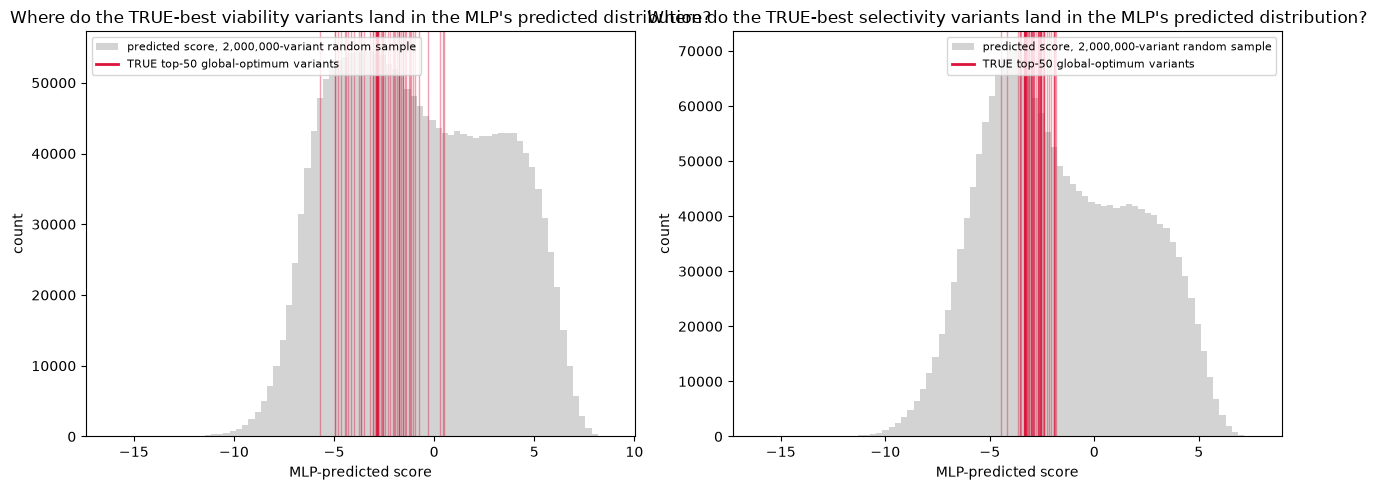

In [33]:
X_best_viab = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_viab].reshape(K_BEST, -1)
X_best_sel  = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_sel].reshape(K_BEST, -1)

pred_best_viab = np.asarray(predict_scores(model_viab, jnp.asarray(X_best_viab)))
pred_best_sel  = np.asarray(predict_scores(model_sel,  jnp.asarray(X_best_sel)))

pct_viab = [100 * (pred_viab_big < v).mean() for v in pred_best_viab]
pct_sel  = [100 * (pred_sel_big  < v).mean() for v in pred_best_sel]

print(f"MLP-predicted score for the TRUE #1 viability variant: {pred_best_viab[0]:.2f}  "
      f"-> {pct_viab[0]:.1f}th percentile of the 200k-sample predicted-score distribution")
print(f"MLP-predicted score for the TRUE #1 selectivity variant: {pred_best_sel[0]:.2f}  "
      f"-> {pct_sel[0]:.1f}th percentile of the 200k-sample predicted-score distribution")
print(f"Median percentile across all top-{K_BEST} TRUE-best viability variants: {np.median(pct_viab):.1f}")
print(f"Median percentile across all top-{K_BEST} TRUE-best selectivity variants: {np.median(pct_sel):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred_pop, pred_best, name in [(axes[0], pred_viab_big, pred_best_viab, "viability"),
                                       (axes[1], pred_sel_big,  pred_best_sel,  "selectivity")]:
    ax.hist(pred_pop, bins=80, color="lightgray",
            label=f"predicted score, {len(pred_pop):,}-variant random sample")
    for v in pred_best:
        ax.axvline(v, color="crimson", alpha=0.4, lw=1)
    ax.axvline(pred_best[0], color="crimson", lw=2, label=f"TRUE top-{K_BEST} global-optimum variants")
    ax.set_xlabel("MLP-predicted score")
    ax.set_ylabel("count")
    ax.set_title(f"Where do the TRUE-best {name} variants land in the MLP's predicted distribution?")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## The opposite direction: are the MLP's OWN top picks actually good?

The previous section took the TRUE best sequences and checked the MLP's opinion of them. This
flips it: scan the ENTIRE `20**7` sequence space with the trained `ProfileMLP` itself (not just
the 200k random sample it was evaluated on), find the sequences IT thinks are best, then check
their TRUE ground-truth score. This is the practically relevant question for actually using
this model to guide a search: if you asked it to propose new candidates beyond the library it
was trained on, would its favorites actually be good, or would it walk confidently into
out-of-distribution predictions that don't hold up against the real `F`/`J`?

In [34]:
@jax.jit
def _onehot_chunk(idx, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    tmp = idx
    digits = []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    seq = jnp.stack(digits[::-1], axis=1).astype(jnp.int32)
    seq_oh = jnp.eye(A, dtype=jnp.float32)[seq].reshape(seq.shape[0], -1)
    return seq, seq_oh


def brute_force_top_k_mlp(model, k=50, chunk_size=1_000_000, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    """Same exhaustive scan as brute_force_top_k, but scores every sequence with the TRAINED
    ProfileMLP instead of the ground-truth F/J -- finds the model's own favorite sequences
    across the ENTIRE space, not just the random sample it was evaluated on. Chunk size is
    smaller than brute_force_top_k's (one-hot (chunk, 140) floats vs. raw (chunk, 7) ints)."""
    total = A ** L
    best_scores = jnp.full((k,), -jnp.inf)
    best_seqs   = jnp.zeros((k, L), dtype=jnp.int32)

    for start in tqdm(range(0, total, chunk_size), desc="MLP brute-force scan"):
        end = min(start + chunk_size, total)
        idx = jnp.arange(start, end)
        seq_chunk, seq_oh_chunk = _onehot_chunk(idx)
        scores_chunk = predict_scores(model, seq_oh_chunk)

        kk = min(k, scores_chunk.shape[0])
        local_vals, local_idx = jax.lax.top_k(scores_chunk, kk)
        local_seqs = seq_chunk[local_idx]

        cand_scores = jnp.concatenate([best_scores, local_vals])
        cand_seqs   = jnp.concatenate([best_seqs, local_seqs], axis=0)
        best_scores, merge_idx = jax.lax.top_k(cand_scores, k)
        best_seqs = cand_seqs[merge_idx]

    return np.asarray(best_seqs), np.asarray(best_scores)


mlp_best_seqs_viab, mlp_best_pred_viab = brute_force_top_k_mlp(model_viab, k=K_BEST)
mlp_best_seqs_sel,  mlp_best_pred_sel  = brute_force_top_k_mlp(model_sel,  k=K_BEST)

# TRUE ground-truth score of the sequences the MLP itself thinks are best.
mlp_best_true_viab = np.asarray(compute_score_array(jnp.asarray(mlp_best_seqs_viab), F_viab, J_viab))
mlp_best_true_sel  = np.asarray(compute_score_array(jnp.asarray(mlp_best_seqs_sel), F_sel_indep, J_sel_indep))

print(f"MLP's #1 predicted-best viability variant   -- predicted={mlp_best_pred_viab[0]:.2f}, "
      f"TRUE score={mlp_best_true_viab[0]:.2f}  (TRUE global optimum: {best_scores_viab[0]:.2f})")
print(f"MLP's #1 predicted-best selectivity variant -- predicted={mlp_best_pred_sel[0]:.2f}, "
      f"TRUE score={mlp_best_true_sel[0]:.2f}  (TRUE global optimum: {best_scores_sel[0]:.2f})")

MLP brute-force scan:   0%|          | 0/1280 [00:00<?, ?it/s]

MLP brute-force scan:   0%|          | 1/1280 [00:03<1:17:09,  3.62s/it]

MLP brute-force scan:   0%|          | 6/1280 [00:03<09:52,  2.15it/s]  

MLP brute-force scan:   1%|          | 12/1280 [00:03<04:09,  5.08it/s]

MLP brute-force scan:   1%|▏         | 17/1280 [00:03<02:35,  8.10it/s]

...

MLP brute-force scan:  99%|█████████▉| 1266/1280 [00:24<00:00, 51.26it/s]

MLP brute-force scan:  99%|█████████▉| 1272/1280 [00:24<00:00, 51.12it/s]

MLP brute-force scan: 100%|█████████▉| 1278/1280 [00:24<00:00, 51.11it/s]

MLP brute-force scan: 100%|██████████| 1280/1280 [00:24<00:00, 51.55it/s]

MLP's #1 predicted-best viability variant   -- predicted=9.29, TRUE score=7.10  (TRUE global optimum: 35.48)
MLP's #1 predicted-best selectivity variant -- predicted=8.54, TRUE score=8.04  (TRUE global optimum: 36.13)


MLP's top-50 predicted-best viability variants   -- median TRUE-score percentile (vs. the 200k random sample): 100.0
MLP's top-50 predicted-best selectivity variants -- median TRUE-score percentile (vs. the 200k random sample): 100.0


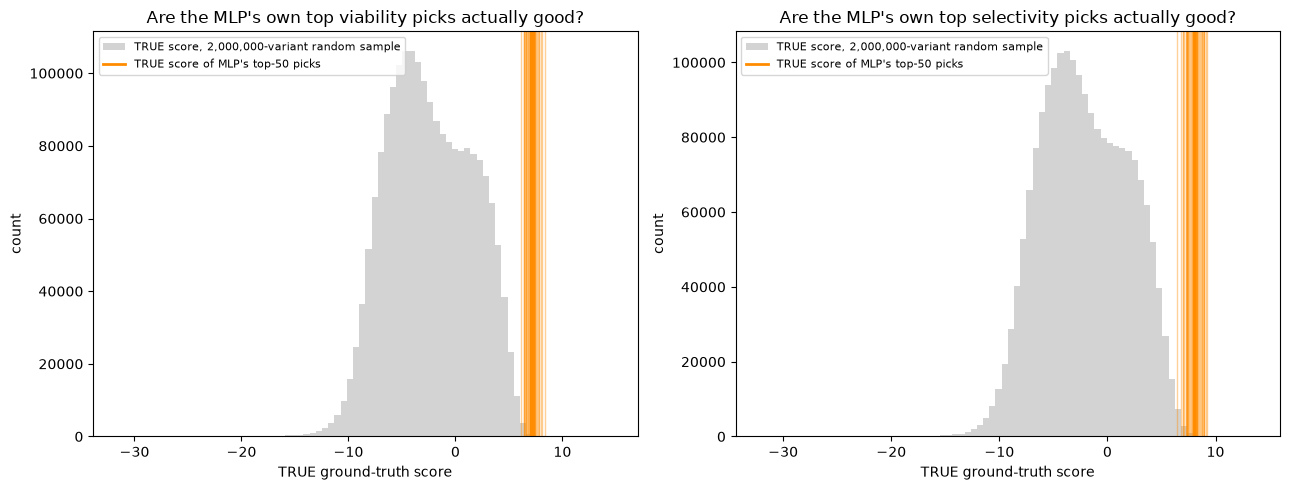

In [35]:
pct_true_viab = [100 * (viab_scores_sample < v).mean() for v in mlp_best_true_viab]
pct_true_sel  = [100 * (sel_scores_sample  < v).mean() for v in mlp_best_true_sel]

print(f"MLP's top-{K_BEST} predicted-best viability variants   -- median TRUE-score percentile "
      f"(vs. the 200k random sample): {np.median(pct_true_viab):.1f}")
print(f"MLP's top-{K_BEST} predicted-best selectivity variants -- median TRUE-score percentile "
      f"(vs. the 200k random sample): {np.median(pct_true_sel):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, true_pop, true_best, name in [(axes[0], viab_scores_sample, mlp_best_true_viab, "viability"),
                                       (axes[1], sel_scores_sample,  mlp_best_true_sel,  "selectivity")]:
    ax.hist(true_pop, bins=80, color="lightgray",
            label=f"TRUE score, {len(true_pop):,}-variant random sample")
    for v in true_best:
        ax.axvline(v, color="darkorange", alpha=0.4, lw=1)
    ax.axvline(true_best[0], color="darkorange", lw=2, label=f"TRUE score of MLP's top-{K_BEST} picks")
    ax.set_xlabel("TRUE ground-truth score")
    ax.set_ylabel("count")
    ax.set_title(f"Are the MLP's own top {name} picks actually good?")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()